# Notebook 04: Anomaly Detection

**Purpose**: Implement two anomaly detection models to identify abnormal drinking behavior in feedlot cattle.

**Models**:
- **Model A — TensorFlow Autoencoder** (primary): Trained on healthy animals only; high reconstruction error = anomaly
- **Model B — Isolation Forest** (comparison): Unsupervised ensemble method with automatic contamination estimation

**Improvements over naive approach**:
1. **Train on healthy data only** — prevents the autoencoder from learning anomalous patterns
2. **Percentile-based threshold** (95th percentile) — robust to right-skewed error distributions
3. **Isolation Forest with `contamination='auto'`** — avoids circular reasoning of setting contamination to known sick fraction
4. **Temporal train/test split** — train on first ~70% of days, evaluate on remaining ~30%

**Input**: `daily_features.csv`  
**Output**: `anomaly_results.csv` — anomaly scores and flags from both models

In [ ]:
# --- Colab Setup (run this cell first if using Google Colab) ---
import os, sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('/content/cattle-anomaly-detection'):
        !git clone https://github.com/dimvsh/cattle-anomaly-detection.git /content/cattle-anomaly-detection
    os.chdir('/content/cattle-anomaly-detection/notebooks')
    !pip install -q -r /content/cattle-anomaly-detection/requirements.txt
    print("Colab setup complete.")
else:
    print("Running locally.")

In [1]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Paths
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data', 'processed')
FIGURES_DIR = os.path.join(PROJECT_DIR, 'figures')

# Load daily features
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'daily_features.csv'), parse_dates=['date'])
df['is_sick'] = df['is_sick'].fillna(0).astype(int)

feature_cols = ['total_daily_duration', 'visit_count', 'avg_visit_duration', 'max_absence_hours']

# Handle NaN in max_absence_hours (first day per animal may lack inter-bout gap)
nan_count = df['max_absence_hours'].isna().sum()
df['max_absence_hours'] = df['max_absence_hours'].fillna(df['max_absence_hours'].median())

print(f"Loaded: {len(df)} animal-days, {df['tag_short'].nunique()} animals")
print(f"Sick animal-days: {df['is_sick'].sum()}, Healthy: {(df['is_sick'] == 0).sum()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"NaN max_absence filled with median: {nan_count} rows")
print(f"Features: {feature_cols}")

Loaded: 793 animal-days, 30 animals
Sick animal-days: 49, Healthy: 744
Date range: 2024-10-11 to 2024-11-07
NaN max_absence filled with median: 1 rows
Features: ['total_daily_duration', 'visit_count', 'avg_visit_duration', 'max_absence_hours']


## Step 1: Temporal Train/Test Split and Normalization

Split data temporally: first ~70% of days for training, remaining ~30% for testing. This ensures the model is evaluated on unseen time periods.

The StandardScaler is fit **only on training data** (healthy animals) to avoid data leakage.

In [2]:
# ---- Temporal split ----
all_dates = sorted(df['date'].unique())
n_days = len(all_dates)
split_idx = int(n_days * 0.7)
train_dates = all_dates[:split_idx]
test_dates = all_dates[split_idx:]

df['split'] = df['date'].apply(lambda d: 'train' if d in train_dates else 'test')

train_df = df[df['split'] == 'train']
test_df = df[df['split'] == 'test']

print(f"Temporal split:")
print(f"  Train: {train_dates[0].date()} to {train_dates[-1].date()} ({len(train_dates)} days, {len(train_df)} animal-days)")
print(f"  Test:  {test_dates[0].date()} to {test_dates[-1].date()} ({len(test_dates)} days, {len(test_df)} animal-days)")
print(f"  Train sick days: {train_df['is_sick'].sum()}, Train healthy days: {(train_df['is_sick'] == 0).sum()}")
print(f"  Test sick days:  {test_df['is_sick'].sum()}, Test healthy days:  {(test_df['is_sick'] == 0).sum()}")

# ---- Fit scaler on TRAINING HEALTHY data only ----
train_healthy = train_df[train_df['is_sick'] == 0]
scaler = StandardScaler()
scaler.fit(train_healthy[feature_cols])

# Transform ALL data using the training-healthy scaler
X_all = scaler.transform(df[feature_cols])
X_train_healthy = scaler.transform(train_healthy[feature_cols])
X_train = scaler.transform(train_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

print(f"\nScaler fit on {len(train_healthy)} training-healthy observations")
print(f"Normalized feature matrix: {X_all.shape}")

Temporal split:
  Train: 2024-10-11 to 2024-10-29 (18 days, 527 animal-days)
  Test:  2024-10-30 to 2024-11-07 (9 days, 266 animal-days)
  Train sick days: 35, Train healthy days: 492
  Test sick days:  14, Test healthy days:  252

Scaler fit on 492 training-healthy observations
Normalized feature matrix: (793, 4)


## Step 2: Model A — TensorFlow Autoencoder (Primary Model)

Architecture: Dense autoencoder (4 → 3 → 2 → 3 → 4)

**Key design decision**: The autoencoder is trained **only on healthy animals from the training period**. This ensures it learns exclusively normal drinking patterns. When it encounters anomalous behavior (sick animals or unusual days), the reconstruction error will be higher because the model has never seen such patterns.

- **Anomaly score**: Mean Squared Error (MSE) between input and reconstruction
- **Threshold**: 95th percentile of reconstruction errors on the training set (robust to right-skewed MSE distribution)

In [3]:
# Build autoencoder
input_dim = len(feature_cols)  # 4

encoder = keras.Sequential([
    keras.layers.Dense(3, activation='relu', input_shape=(input_dim,)),
    keras.layers.Dense(2, activation='relu')  # bottleneck
], name='encoder')

decoder = keras.Sequential([
    keras.layers.Dense(3, activation='relu', input_shape=(2,)),
    keras.layers.Dense(input_dim, activation='linear')  # reconstruct original scale
], name='decoder')

autoencoder = keras.Sequential([encoder, decoder], name='autoencoder')
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')

autoencoder.summary()
print(f"\nTraining data: {len(X_train_healthy)} healthy animal-days from the training period")

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 2)              │            23 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 4)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48 (192.00 B)

 Trainable params: 48 (192.00 B)

 Non-trainable params: 0 (0.00 B)


Training data: 492 healthy animal-days from the training period


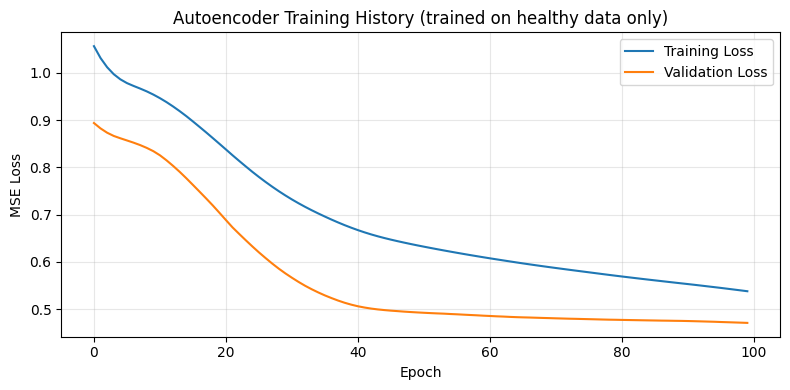

Final training loss: 0.5377
Final validation loss: 0.4707


In [4]:
# Train autoencoder on HEALTHY training data only
history = autoencoder.fit(
    X_train_healthy, X_train_healthy,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    shuffle=True,
    verbose=0
)

# Plot training history
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(history.history['loss'], label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training History (trained on healthy data only)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig8_autoencoder_training.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

In [5]:
# Score ALL data using the healthy-trained autoencoder
X_all_reconstructed = autoencoder.predict(X_all, verbose=0)
ae_mse = np.mean((X_all - X_all_reconstructed) ** 2, axis=1)

# Set threshold: 95th percentile of TRAINING reconstruction errors
# (more robust than mean + 2*std for right-skewed distributions)
train_mse = np.mean((X_train_healthy - autoencoder.predict(X_train_healthy, verbose=0)) ** 2, axis=1)
ae_threshold = np.percentile(train_mse, 95)

df['ae_score'] = ae_mse
df['ae_anomaly'] = (ae_mse > ae_threshold).astype(int)

print(f"Autoencoder results:")
print(f"  Training MSE — mean: {train_mse.mean():.4f}, std: {train_mse.std():.4f}, 95th pctl: {ae_threshold:.4f}")
print(f"  Threshold (95th percentile of training errors): {ae_threshold:.4f}")
print(f"  Total anomalies flagged: {df['ae_anomaly'].sum()} / {len(df)} ({df['ae_anomaly'].mean()*100:.1f}%)")
print(f"\n  Train period: {train_df.shape[0]} days, {df.loc[train_df.index, 'ae_anomaly'].sum()} flagged")
print(f"  Test period:  {test_df.shape[0]} days, {df.loc[test_df.index, 'ae_anomaly'].sum()} flagged")
print(f"\n  Among sick animal-days ({df['is_sick'].sum()} total): {df[df['is_sick'] == 1]['ae_anomaly'].sum()} flagged")
print(f"  Among healthy animal-days ({(df['is_sick'] == 0).sum()} total): {df[df['is_sick'] == 0]['ae_anomaly'].sum()} flagged")
print(f"\n  Mean AE score — healthy: {df[df['is_sick'] == 0]['ae_score'].mean():.4f}, sick: {df[df['is_sick'] == 1]['ae_score'].mean():.4f} "
      f"({df[df['is_sick'] == 1]['ae_score'].mean() / df[df['is_sick'] == 0]['ae_score'].mean():.1f}x)")

Autoencoder results:
  Training MSE — mean: 0.5299, std: 0.8608, 95th pctl: 2.2373
  Threshold (95th percentile of training errors): 2.2373
  Total anomalies flagged: 32 / 793 (4.0%)

  Train period: 527 days, 29 flagged
  Test period:  266 days, 3 flagged

  Among sick animal-days (49 total): 6 flagged
  Among healthy animal-days (744 total): 26 flagged

  Mean AE score — healthy: 0.4219, sick: 0.7635 (1.8x)


## Step 3: Model B — Isolation Forest (Comparison Model)

Isolation Forest isolates anomalies via random partitioning. Anomalies require fewer splits to isolate, yielding higher anomaly scores.

- `contamination='auto'` — lets the algorithm determine the threshold from the data (avoids circular reasoning of presetting the expected anomaly rate)
- `n_estimators=100` — number of isolation trees
- Trained on the **training period data** (all animals — IF is fully unsupervised)

In [6]:
# Train Isolation Forest on training period data
iso_forest = IsolationForest(
    contamination='auto',
    n_estimators=100,
    random_state=42
)
iso_forest.fit(X_train)

# Score ALL data
# sklearn returns negative scores (more negative = more anomalous)
# We negate so higher = more anomalous (consistent with autoencoder)
df['if_score'] = -iso_forest.score_samples(X_all)
df['if_anomaly'] = (iso_forest.predict(X_all) == -1).astype(int)

print(f"Isolation Forest results (contamination='auto'):")
print(f"  Trained on: {len(X_train)} animal-days from training period")
print(f"  Total anomalies flagged: {df['if_anomaly'].sum()} / {len(df)} ({df['if_anomaly'].mean()*100:.1f}%)")
print(f"\n  Train period: {train_df.shape[0]} days, {df.loc[train_df.index, 'if_anomaly'].sum()} flagged")
print(f"  Test period:  {test_df.shape[0]} days, {df.loc[test_df.index, 'if_anomaly'].sum()} flagged")
print(f"\n  Among sick animal-days ({df['is_sick'].sum()} total): {df[df['is_sick'] == 1]['if_anomaly'].sum()} flagged")
print(f"  Among healthy animal-days ({(df['is_sick'] == 0).sum()} total): {df[df['is_sick'] == 0]['if_anomaly'].sum()} flagged")
print(f"\n  Mean IF score — healthy: {df[df['is_sick'] == 0]['if_score'].mean():.4f}, sick: {df[df['is_sick'] == 1]['if_score'].mean():.4f} "
      f"({df[df['is_sick'] == 1]['if_score'].mean() / df[df['is_sick'] == 0]['if_score'].mean():.1f}x)")

Isolation Forest results (contamination='auto'):
  Trained on: 527 animal-days from training period
  Total anomalies flagged: 113 / 793 (14.2%)

  Train period: 527 days, 104 flagged
  Test period:  266 days, 9 flagged

  Among sick animal-days (49 total): 12 flagged
  Among healthy animal-days (744 total): 101 flagged

  Mean IF score — healthy: 0.4322, sick: 0.4453 (1.0x)


## Step 4: Visualize Anomaly Scores

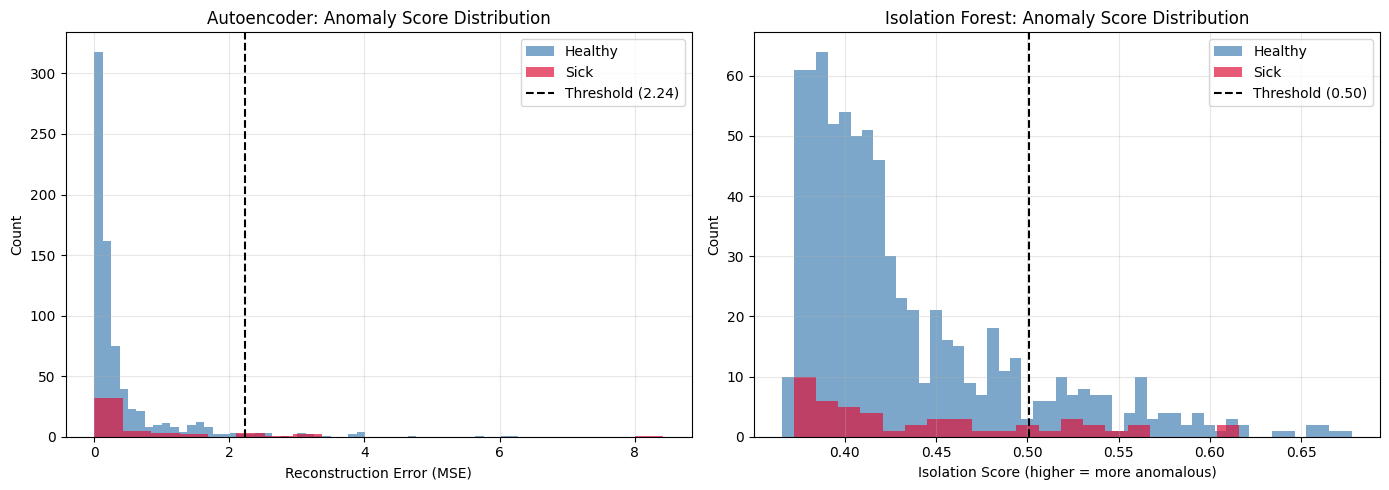

In [7]:
# --- Fig 9: Anomaly score distributions (healthy vs sick) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Autoencoder
ax = axes[0]
ax.hist(df[df['is_sick'] == 0]['ae_score'], bins=50, alpha=0.7, label='Healthy', color='steelblue')
ax.hist(df[df['is_sick'] == 1]['ae_score'], bins=20, alpha=0.7, label='Sick', color='crimson')
ax.axvline(ae_threshold, color='black', linestyle='--', linewidth=1.5, label=f'Threshold ({ae_threshold:.2f})')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Count')
ax.set_title('Autoencoder: Anomaly Score Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Isolation Forest
ax = axes[1]
if_flagged = df[df['if_anomaly'] == 1]
if_threshold = if_flagged['if_score'].min() if len(if_flagged) > 0 else df['if_score'].quantile(0.95)
ax.hist(df[df['is_sick'] == 0]['if_score'], bins=50, alpha=0.7, label='Healthy', color='steelblue')
ax.hist(df[df['is_sick'] == 1]['if_score'], bins=20, alpha=0.7, label='Sick', color='crimson')
ax.axvline(if_threshold, color='black', linestyle='--', linewidth=1.5, label=f'Threshold ({if_threshold:.2f})')
ax.set_xlabel('Isolation Score (higher = more anomalous)')
ax.set_ylabel('Count')
ax.set_title('Isolation Forest: Anomaly Score Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig9_anomaly_score_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

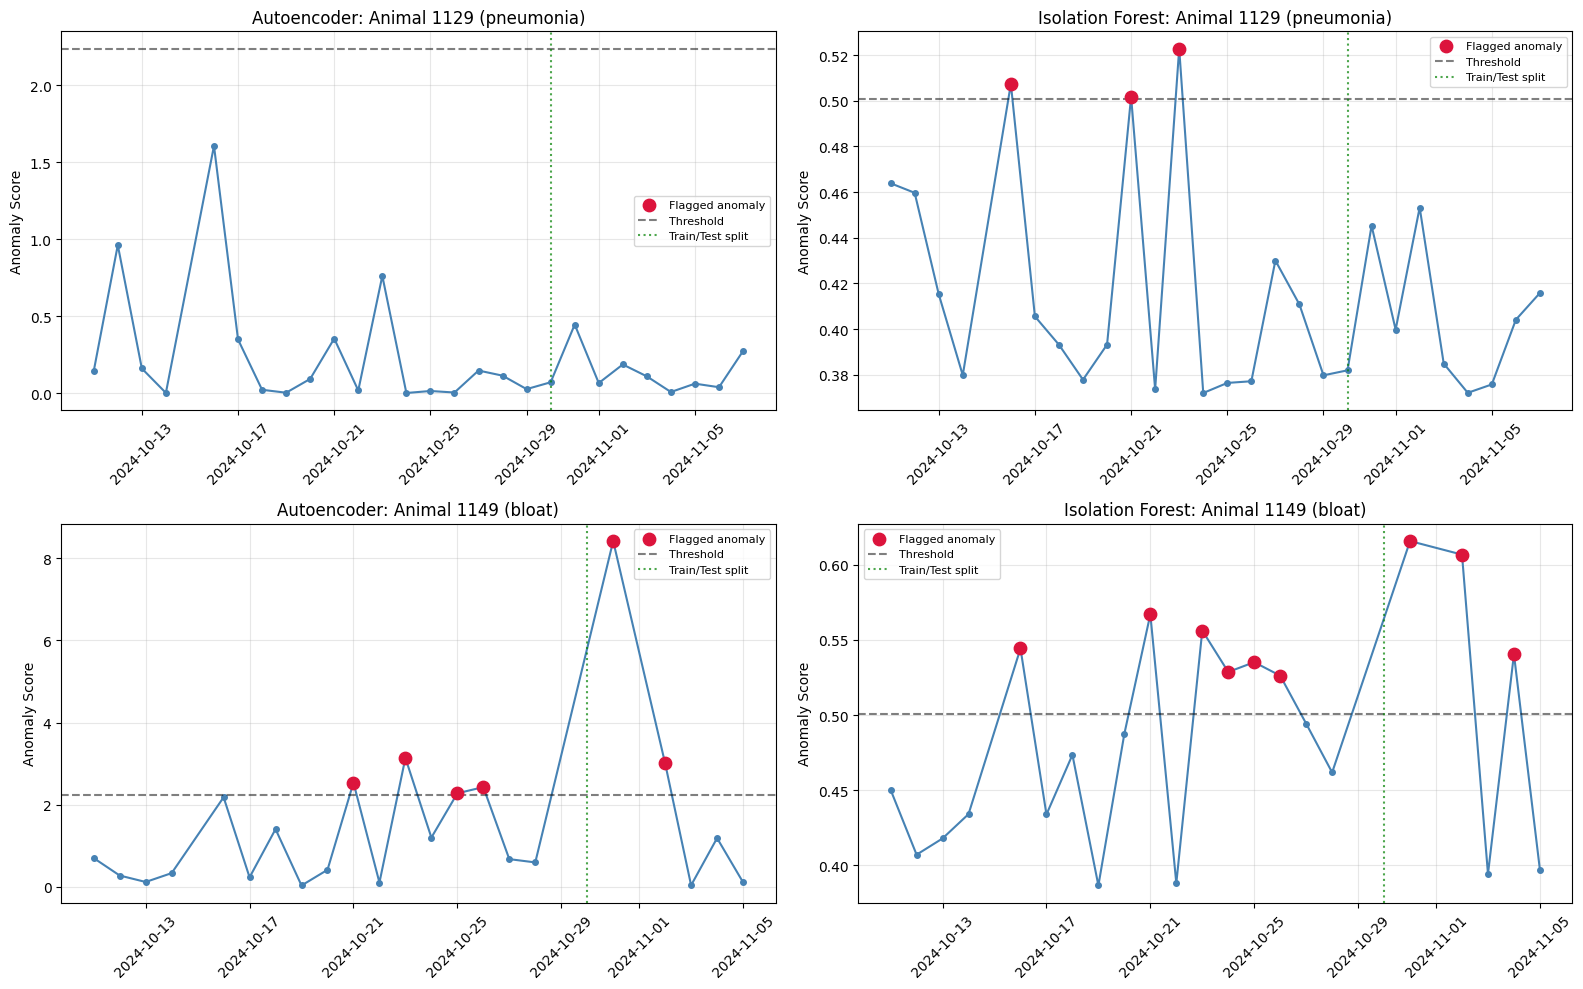

In [8]:
# --- Fig 10: Anomaly scores over time for sick animals ---
# Includes train/test split boundary
sick_tags = [1129, 1149]
sick_labels = {1129: 'Animal 1129 (pneumonia)', 1149: 'Animal 1149 (bloat)'}
split_date = test_dates[0]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col_idx, (model_name, score_col, anom_col, threshold_val) in enumerate([
    ('Autoencoder', 'ae_score', 'ae_anomaly', ae_threshold),
    ('Isolation Forest', 'if_score', 'if_anomaly', if_threshold)
]):
    for row_idx, tag in enumerate(sick_tags):
        ax = axes[row_idx, col_idx]
        animal_data = df[df['tag_short'] == tag].sort_values('date')
        
        # Plot score over time
        ax.plot(animal_data['date'], animal_data[score_col], 
                color='steelblue', marker='o', markersize=4, linewidth=1.5)
        
        # Highlight anomaly days
        anomalies = animal_data[animal_data[anom_col] == 1]
        ax.scatter(anomalies['date'], anomalies[score_col], 
                   color='crimson', s=80, zorder=5, label='Flagged anomaly')
        
        # Threshold line
        ax.axhline(threshold_val, color='black', linestyle='--', alpha=0.5, label='Threshold')
        
        # Train/test split boundary
        ax.axvline(split_date, color='green', linestyle=':', alpha=0.7, label='Train/Test split')
        
        ax.set_title(f'{model_name}: {sick_labels[tag]}')
        ax.set_ylabel('Anomaly Score')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig10_sick_animals_anomaly_timeline.png'), dpi=150, bbox_inches='tight')
plt.show()

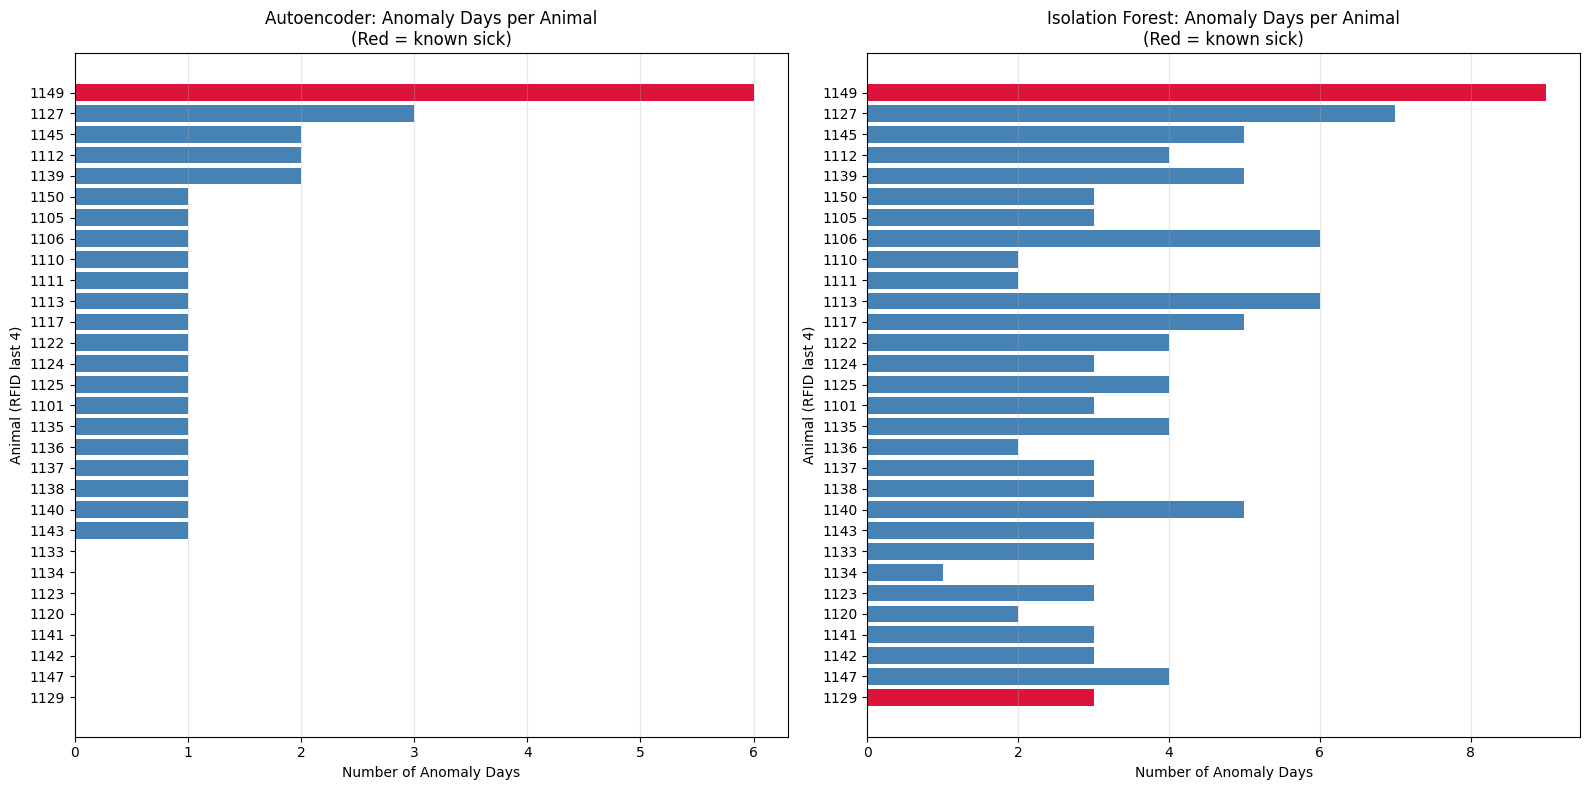

Top 10 animals by autoencoder anomaly count:
  Animal 1149.0: 6 anomaly days (27%) *** SICK ***
  Animal 1127.0: 3 anomaly days (11%)
  Animal 1145.0: 2 anomaly days (7%)
  Animal 1112.0: 2 anomaly days (7%)
  Animal 1139.0: 2 anomaly days (7%)
  Animal 1124.0: 1 anomaly days (4%)
  Animal 1150.0: 1 anomaly days (4%)
  Animal 1105.0: 1 anomaly days (4%)
  Animal 1106.0: 1 anomaly days (4%)
  Animal 1110.0: 1 anomaly days (4%)


In [9]:
# --- Fig 11: Anomaly frequency per animal (both models) ---
anomaly_counts = df.groupby('tag_short').agg(
    ae_anomalies=('ae_anomaly', 'sum'),
    if_anomalies=('if_anomaly', 'sum'),
    is_sick=('is_sick', 'first'),
    total_days=('ae_anomaly', 'count')
).reset_index()
anomaly_counts['ae_rate'] = anomaly_counts['ae_anomalies'] / anomaly_counts['total_days'] * 100
anomaly_counts['if_rate'] = anomaly_counts['if_anomalies'] / anomaly_counts['total_days'] * 100
anomaly_counts = anomaly_counts.sort_values('ae_anomalies', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, model, anom_col, rate_col in [
    (axes[0], 'Autoencoder', 'ae_anomalies', 'ae_rate'),
    (axes[1], 'Isolation Forest', 'if_anomalies', 'if_rate')
]:
    colors = ['crimson' if s == 1 else 'steelblue' for s in anomaly_counts['is_sick']]
    bars = ax.barh(anomaly_counts['tag_short'].astype(str), anomaly_counts[anom_col], color=colors)
    ax.set_xlabel('Number of Anomaly Days')
    ax.set_ylabel('Animal (RFID last 4)')
    ax.set_title(f'{model}: Anomaly Days per Animal\n(Red = known sick)')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig11_anomaly_frequency_per_animal.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print top anomaly animals
print("Top 10 animals by autoencoder anomaly count:")
top = anomaly_counts.sort_values('ae_anomalies', ascending=False).head(10)
for _, row in top.iterrows():
    sick_marker = " *** SICK ***" if row['is_sick'] == 1 else ""
    print(f"  Animal {row['tag_short']}: {row['ae_anomalies']:.0f} anomaly days ({row['ae_rate']:.0f}%){sick_marker}")

## Step 5: Model Comparison

In [10]:
# --- Model Comparison ---

# Agreement
both_flagged = ((df['ae_anomaly'] == 1) & (df['if_anomaly'] == 1)).sum()
ae_only = ((df['ae_anomaly'] == 1) & (df['if_anomaly'] == 0)).sum()
if_only = ((df['ae_anomaly'] == 0) & (df['if_anomaly'] == 1)).sum()
neither = ((df['ae_anomaly'] == 0) & (df['if_anomaly'] == 0)).sum()

print("=== Model Agreement (all data) ===")
print(f"  Both flagged:          {both_flagged}")
print(f"  Autoencoder only:      {ae_only}")
print(f"  Isolation Forest only: {if_only}")
print(f"  Neither flagged:       {neither}")

# Per sick animal — overall and by split
print("\n=== Detection of Known Sick Animals ===")
for tag in [1129, 1149]:
    animal = df[df['tag_short'] == tag]
    label = 'pneumonia' if tag == 1129 else 'bloat'
    n_days = len(animal)
    ae_det = animal['ae_anomaly'].sum()
    if_det = animal['if_anomaly'].sum()
    both_det = ((animal['ae_anomaly'] == 1) & (animal['if_anomaly'] == 1)).sum()
    
    # Test period only
    animal_test = animal[animal['split'] == 'test']
    n_test = len(animal_test)
    ae_test = animal_test['ae_anomaly'].sum() if n_test > 0 else 0
    if_test = animal_test['if_anomaly'].sum() if n_test > 0 else 0
    
    print(f"\n  Animal {tag} ({label}):")
    print(f"    Overall ({n_days} days):  AE flagged {ae_det}, IF flagged {if_det}, Both {both_det}")
    print(f"    Test period ({n_test} days): AE flagged {ae_test}, IF flagged {if_test}")

# Score separation
print("\n=== Mean Anomaly Scores: Sick vs Healthy ===")
for model, score_col in [('Autoencoder MSE', 'ae_score'), ('Isolation Forest', 'if_score')]:
    sick_mean = df[df['is_sick'] == 1][score_col].mean()
    healthy_mean = df[df['is_sick'] == 0][score_col].mean()
    ratio = sick_mean / healthy_mean if healthy_mean > 0 else float('inf')
    print(f"  {model}: healthy={healthy_mean:.4f}, sick={sick_mean:.4f} ({ratio:.1f}x)")

# Test-period-only scores
print("\n=== Test Period Scores ===")
test_data = df[df['split'] == 'test']
for model, score_col in [('Autoencoder MSE', 'ae_score'), ('Isolation Forest', 'if_score')]:
    sick_mean = test_data[test_data['is_sick'] == 1][score_col].mean() if test_data['is_sick'].sum() > 0 else float('nan')
    healthy_mean = test_data[test_data['is_sick'] == 0][score_col].mean()
    ratio = sick_mean / healthy_mean if healthy_mean > 0 and not np.isnan(sick_mean) else float('nan')
    print(f"  {model}: healthy={healthy_mean:.4f}, sick={sick_mean:.4f} ({ratio:.1f}x)")

=== Model Agreement (all data) ===
  Both flagged:          32
  Autoencoder only:      0
  Isolation Forest only: 81
  Neither flagged:       680

=== Detection of Known Sick Animals ===

  Animal 1129 (pneumonia):
    Overall (27 days):  AE flagged 0, IF flagged 3, Both 0
    Test period (9 days): AE flagged 0, IF flagged 0

  Animal 1149 (bloat):
    Overall (22 days):  AE flagged 6, IF flagged 9, Both 6
    Test period (5 days): AE flagged 2, IF flagged 3

=== Mean Anomaly Scores: Sick vs Healthy ===
  Autoencoder MSE: healthy=0.4219, sick=0.7635 (1.8x)
  Isolation Forest: healthy=0.4322, sick=0.4453 (1.0x)

=== Test Period Scores ===
  Autoencoder MSE: healthy=0.2111, sick=1.0013 (4.7x)
  Isolation Forest: healthy=0.4116, sick=0.4419 (1.1x)


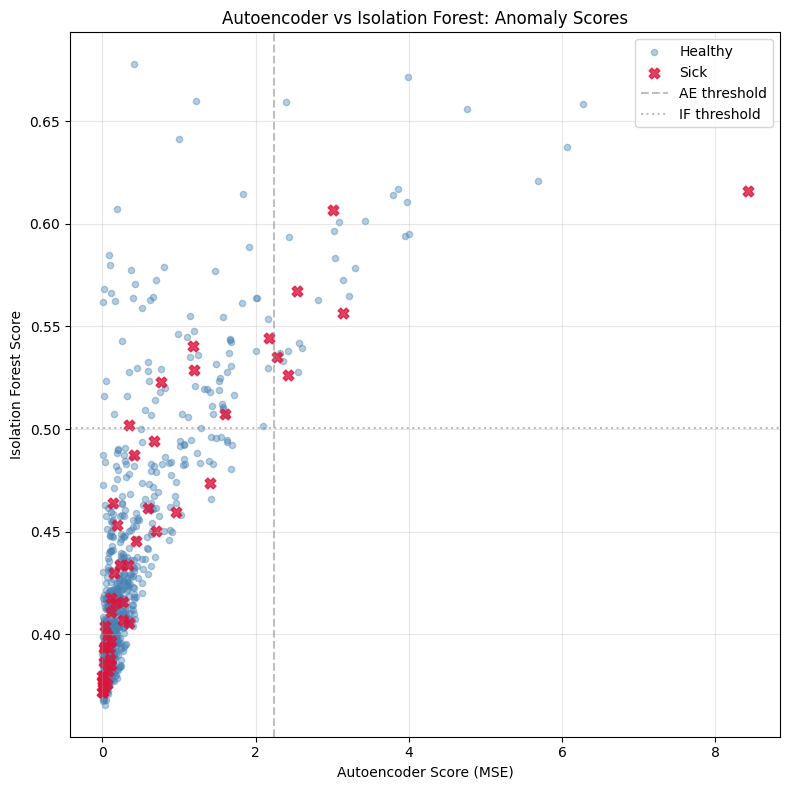

Correlation between AE and IF scores: 0.755


In [11]:
# --- Fig 12: Scatter — Autoencoder vs Isolation Forest scores ---
fig, ax = plt.subplots(figsize=(8, 8))

healthy = df[df['is_sick'] == 0]
sick = df[df['is_sick'] == 1]

ax.scatter(healthy['ae_score'], healthy['if_score'], alpha=0.4, s=20, c='steelblue', label='Healthy')
ax.scatter(sick['ae_score'], sick['if_score'], alpha=0.8, s=60, c='crimson', marker='X', label='Sick')

ax.axvline(ae_threshold, color='gray', linestyle='--', alpha=0.5, label='AE threshold')
ax.axhline(if_threshold, color='gray', linestyle=':', alpha=0.5, label='IF threshold')

ax.set_xlabel('Autoencoder Score (MSE)')
ax.set_ylabel('Isolation Forest Score')
ax.set_title('Autoencoder vs Isolation Forest: Anomaly Scores')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig12_ae_vs_if_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

# Correlation between the two scores
corr = df['ae_score'].corr(df['if_score'])
print(f"Correlation between AE and IF scores: {corr:.3f}")

## Step 6: Export Results

In [12]:
# Export full results
output_cols = [
    'tag_short', 'date', 'split',
    'total_daily_duration', 'visit_count', 'avg_visit_duration', 'max_absence_hours',
    'is_sick', 'health_note',
    'ae_score', 'ae_anomaly',
    'if_score', 'if_anomaly'
]
results = df[output_cols].copy()
results.to_csv(os.path.join(PROCESSED_DIR, 'anomaly_results.csv'), index=False)

print(f"Exported anomaly_results.csv: {len(results)} rows")
print(f"Columns: {list(results.columns)}")

# Summary table for thesis
print(f"\n{'='*75}")
print(f"SUMMARY TABLE FOR THESIS")
print(f"{'='*75}")
print(f"{'Metric':<45} {'Autoencoder':>13} {'Isolation Forest':>15}")
print(f"{'-'*75}")
print(f"{'Training data':<45} {'healthy only':>13} {'all animals':>15}")
print(f"{'Threshold method':<45} {'95th pctl':>13} {'auto':>15}")
print(f"{'Total anomalies flagged':<45} {df['ae_anomaly'].sum():>13} {df['if_anomaly'].sum():>15}")
print(f"{'Anomaly rate':<45} {df['ae_anomaly'].mean()*100:>12.1f}% {df['if_anomaly'].mean()*100:>14.1f}%")
for tag, label in [(1129, 'pneumonia'), (1149, 'bloat')]:
    a = df[df['tag_short'] == tag]
    n = len(a)
    ae_d = a['ae_anomaly'].sum()
    if_d = a['if_anomaly'].sum()
    print(f"{'Animal ' + str(tag) + f' ({label}) detected':<45} {f'{ae_d}/{n} days':>13} {f'{if_d}/{n} days':>15}")
ae_fp = df[(df['is_sick'] == 0) & (df['ae_anomaly'] == 1)].shape[0]
if_fp = df[(df['is_sick'] == 0) & (df['if_anomaly'] == 1)].shape[0]
print(f"{'False positives (healthy flagged)':<45} {ae_fp:>13} {if_fp:>15}")
sick_ae = df[df['is_sick'] == 1]['ae_score'].mean()
hlth_ae = df[df['is_sick'] == 0]['ae_score'].mean()
sick_if = df[df['is_sick'] == 1]['if_score'].mean()
hlth_if = df[df['is_sick'] == 0]['if_score'].mean()
print(f"{'Sick/healthy score ratio':<45} {sick_ae/hlth_ae:>12.1f}x {sick_if/hlth_if:>14.1f}x")

Exported anomaly_results.csv: 793 rows
Columns: ['tag_short', 'date', 'split', 'total_daily_duration', 'visit_count', 'avg_visit_duration', 'max_absence_hours', 'is_sick', 'health_note', 'ae_score', 'ae_anomaly', 'if_score', 'if_anomaly']

SUMMARY TABLE FOR THESIS
Metric                                          Autoencoder Isolation Forest
---------------------------------------------------------------------------
Training data                                  healthy only     all animals
Threshold method                                  95th pctl            auto
Total anomalies flagged                                  32             113
Anomaly rate                                           4.0%           14.2%
Animal 1129 (pneumonia) detected                  0/27 days       3/27 days
Animal 1149 (bloat) detected                      6/22 days       9/22 days
False positives (healthy flagged)                        26             101
Sick/healthy score ratio                          